In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

In [35]:
dataset = pd.read_excel('./AirQualityUCI.xlsx')

In [36]:
dataset.head()

,NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,CO(GT),PT08.S1(CO)
0,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754,2.6,1360.00
1,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487,2.0,1292.25
2,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239,2.2,1402.00
3,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713,2.2,1375.50
4,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794,1.6,1272.25


CO(GT) : True hourly averaged concentration CO in mg/m^3 (reference analyzer)

In [37]:
dataset.isnull().sum()

NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
CO(GT)           0
PT08.S1(CO)      0
dtype: int64

In [38]:
X = dataset.iloc[:,:-1]
y = dataset.iloc[:,[-1]]
print(X)
print(y)

      NMHC(GT)   C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  \
0          150  11.881723        1045.50    166.0       1056.25    113.0   
1          112   9.397165         954.75    103.0       1173.75     92.0   
2           88   8.997817         939.25    131.0       1140.00    114.0   
3           80   9.228796         948.25    172.0       1092.00    122.0   
4           51   6.518224         835.50    131.0       1205.00    116.0   
...        ...        ...            ...      ...           ...      ...   
9352      -200  13.529605        1101.25    471.7        538.50    189.8   
9353      -200  11.355157        1027.00    353.3        603.75    179.2   
9354      -200  12.374538        1062.50    293.0        603.25    174.7   
9355      -200   9.547187         960.50    234.5        701.50    155.7   
9356      -200  11.932060        1047.25    265.2        654.00    167.7   

      PT08.S4(NO2)  PT08.S5(O3)       T         RH        AH  CO(GT)  
0          1692.

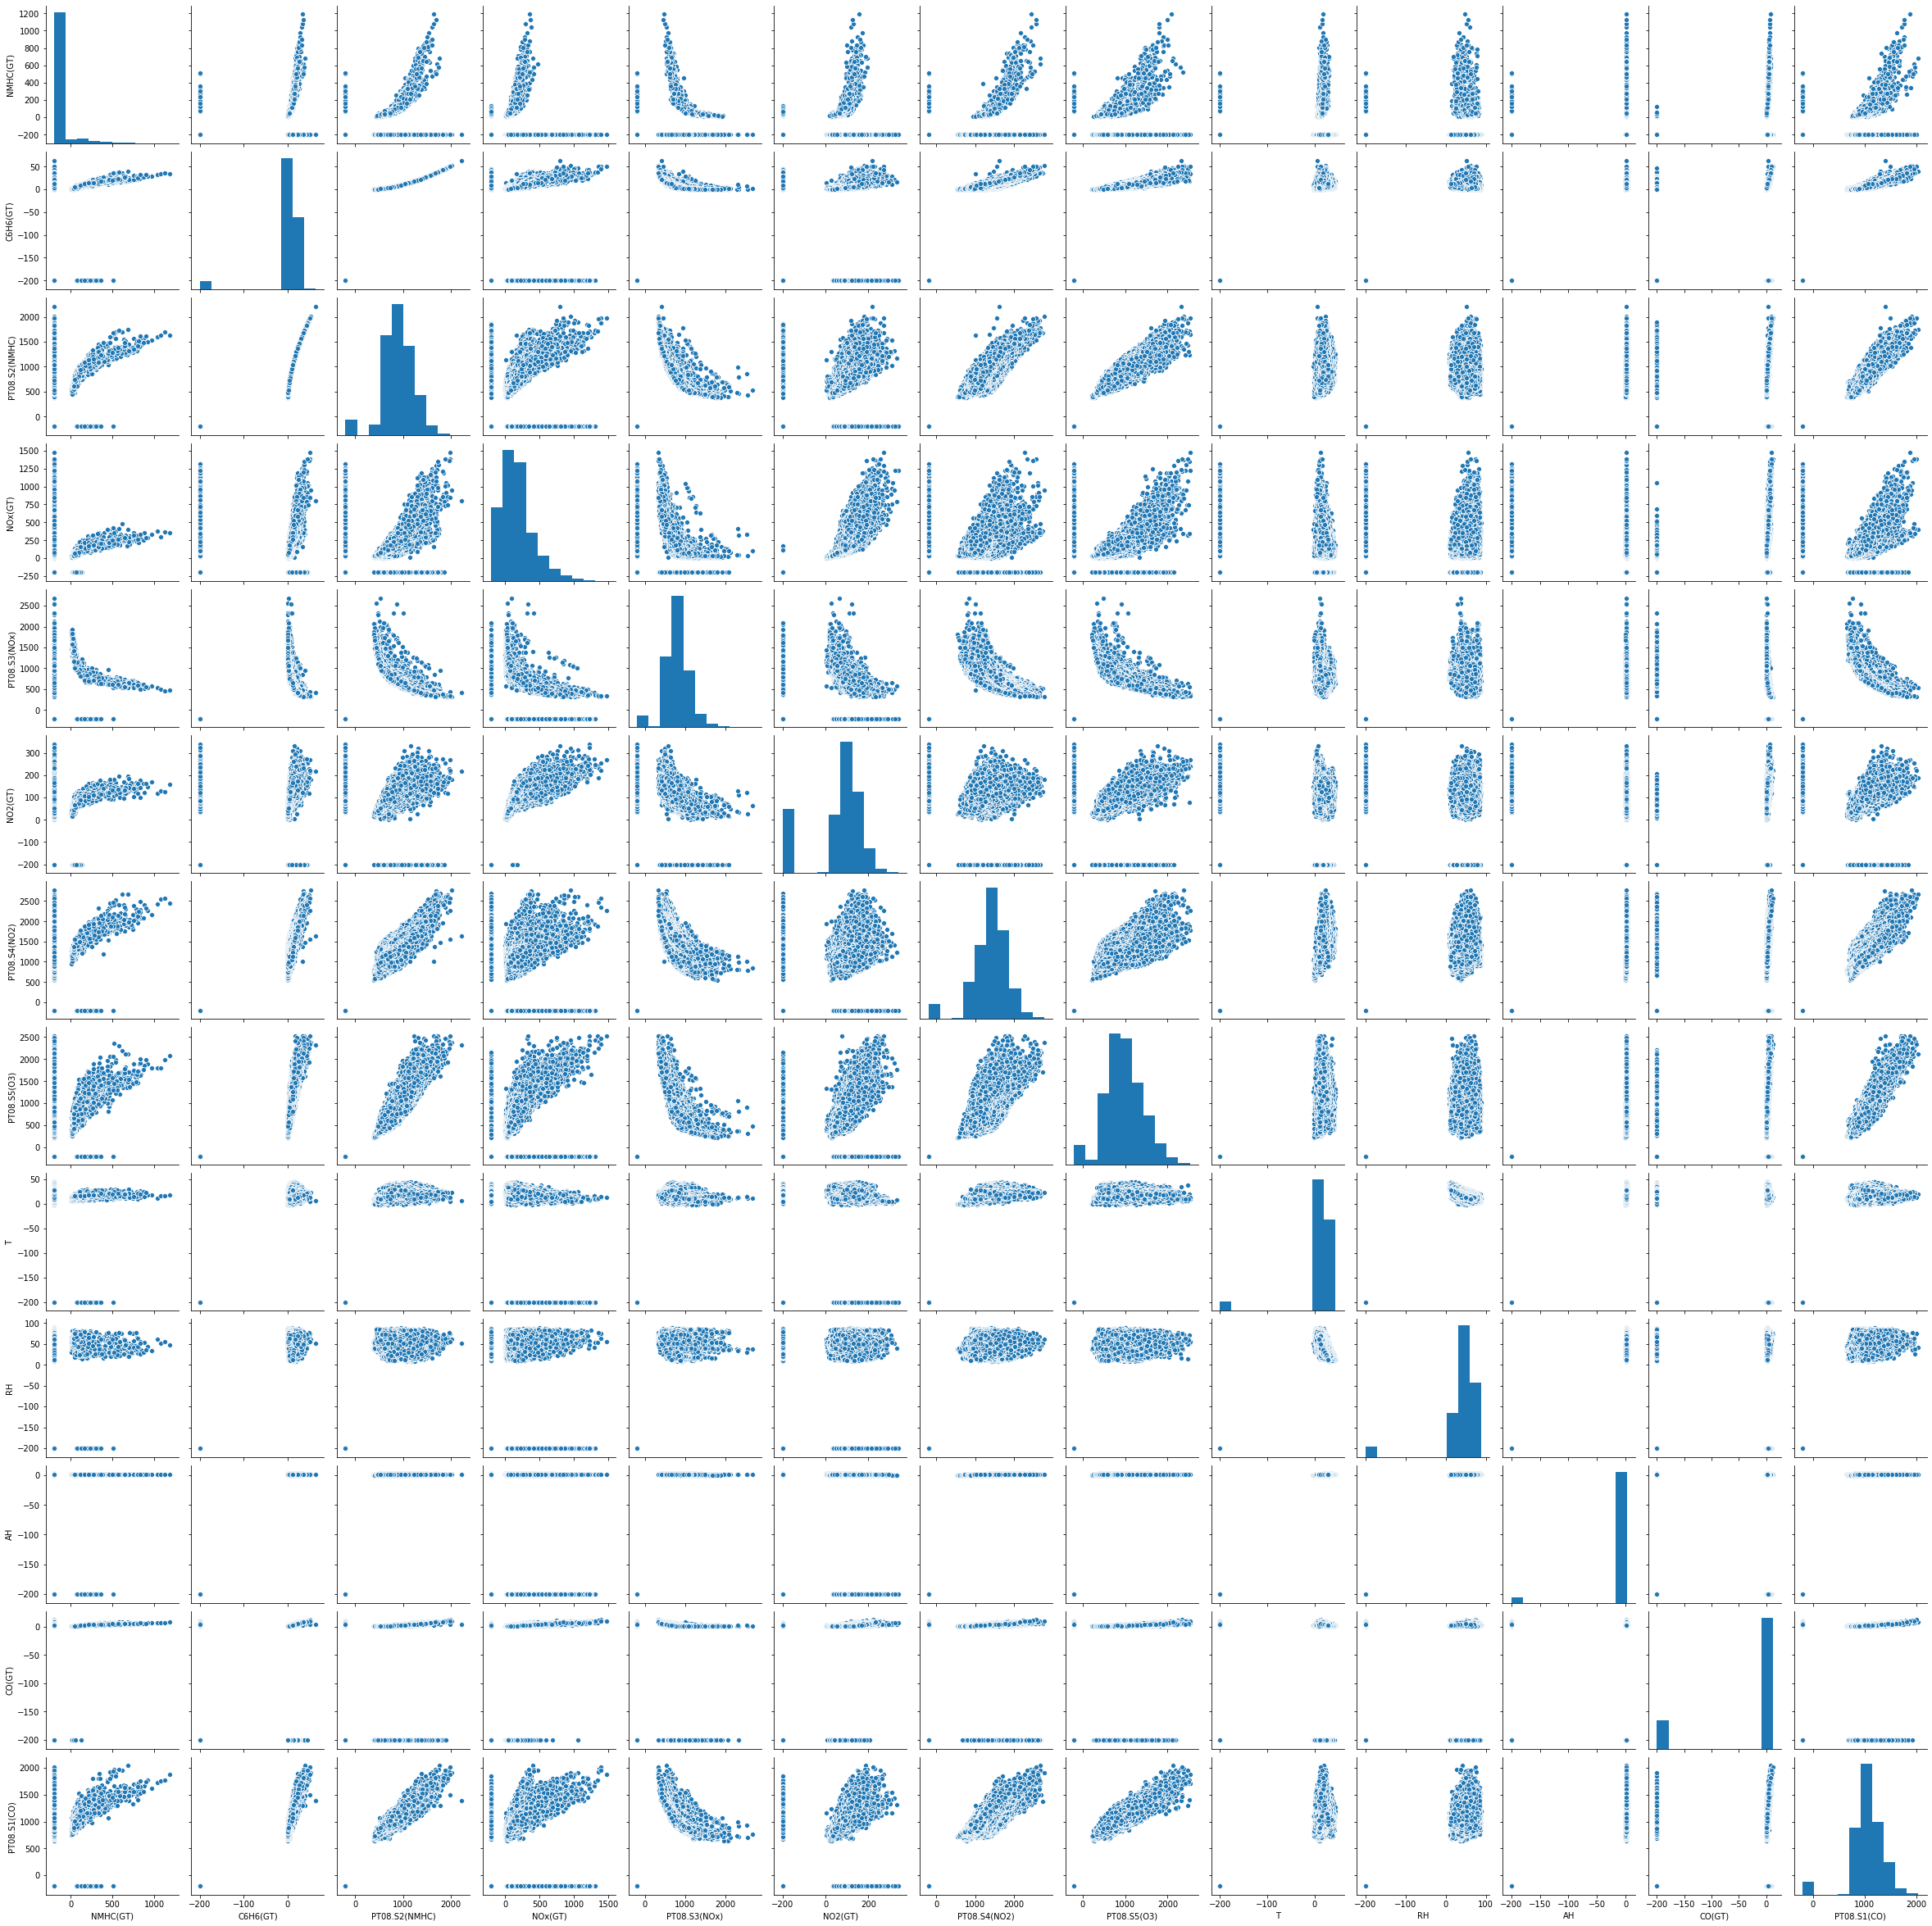

In [39]:
sns.pairplot(dataset)
plt.show()

In [40]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,train_size=0.8,test_size=0.2)


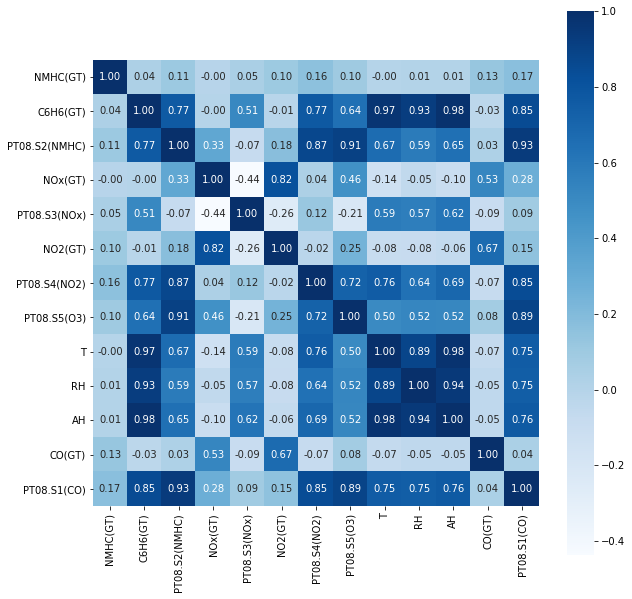

In [41]:
correlation = dataset.corr()

plt.figure(figsize=(10,10))
sns.heatmap(correlation, annot=True,fmt = '.2f', cmap="Blues",square=True)

In [50]:
from sklearn.linear_model import LinearRegression

mlr = LinearRegression()
pr = LinearRegression()

mlr.fit(x_train,y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [51]:
y_predict = mlr.predict(x_test)
print(mlr.coef_)
print(mlr.intercept_)

[[ 2.19915178e-01  8.05375303e+00  4.33731273e-02  4.27417659e-02
  -1.34872841e-01 -3.29942868e-03  8.04564049e-02  1.95410227e-01
  -1.13232115e+00  7.35165816e-01 -3.02146151e+00 -6.81706612e-03]]
[788.46889758]


In [63]:
print(x_train.shape)
print(y_train.shape)

(7485, 12)
(7485, 1)


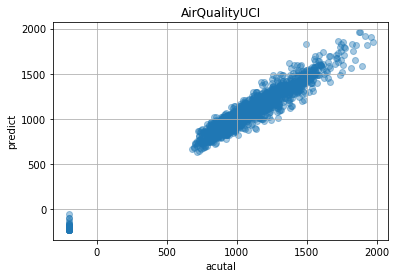

In [56]:
plt.title('AirQualityUCI')
plt.xlabel('acutal')
plt.ylabel('predict')
plt.grid(True)
plt.scatter(y_test,y_predict,alpha=0.4)
plt.show()


accuracy

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

r2 = r2_score(y_test,y_predict)
print(r2)

0.9490496302246193


성능 RMSE

In [20]:

np.round(np.sqrt(mean_squared_error(y_test,y_predict)),2)

71.9